# ET-DHP: online compensation after an M1 failure

In this notebook, an **ET-DHP (Event-Triggered Dual Heuristic Programming)** controller drives a nonlinear 6-DoF quadrotor under a single-motor failure. The vehicle starts at an altitude of **3 m**, tracks a sinusoidal reference with **0.5 m** amplitude, and at **t = 20 s** motor M1 loses effectiveness. The episode then continues for another **10 seconds** to check whether tracking remains close to the healthy case.

## Scenario

| Parameter | Value |
|---|---|
| Duration | 30 s |
| Initial altitude | 3 m (`z0 = -3 m`, NED) |
| Reference | `h_ref(t) = 3 + 0.5 sin(2πt / 10)` m |
| Failure | M1 loses effectiveness |
| Failure time | `t = 20 s` |
| Post-failure evaluation window | `20-30 s` |

## No PD and no precomputed failure matrix

There is no altitude PD and no attitude PD at runtime. The controller uses two ET-DHP actors:

* altitude ET-DHP commands `ΔT` relative to `T_hover = m·g`;
* angular-rate ET-DHP commands moments `[τx, τy, τz]` to suppress angular rates after the asymmetric failure.

The controller does not receive the true `μ` from the damage model and does not use a precomputed `FAULT_RECONFIG`. After the failure, it estimates the motor map online from observed rotor-level command/effective pairs:

```python
omega2_eff ≈ diag(mu_hat) @ omega2_cmd
B_hat = M @ diag(mu_hat) @ inv(M)
```

Here `M` is the known nominal allocation matrix from the healthy quadrotor geometry, while `mu_hat` and `B_hat` are identified online from motor response. Compensation is then computed as:

```python
u_desired = [T_hover + ΔT_ETDHP, τx_ETDHP, τy_ETDHP, τz_ETDHP]
u_cmd = solve(B_hat, u_desired)
action = ALLOCATOR.unmix(u_cmd)
```

`DAMAGE_MU` below is used only to create the failure inside the environment; the controller does not read it.


## 1. Imports


In [1]:
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from tensoraerospace.aerospacemodel.quadrotor.allocation import default_allocator
from tensoraerospace.aerospacemodel.quadrotor.damage import DamageProfile, RotorDamageEvent
from tensoraerospace.aerospacemodel.quadrotor.nonlinear import NonlinearQuadrotor
from tensoraerospace.agent.et_dhp import ETDHPAgent, ETDHPConfig
from tensoraerospace.envs.quadrotor import NonlinearQuadrotorEnv

## 2. Simulation Parameters

The reference is defined in altitude `h = -z`, while the quadrotor model uses the NED coordinate `z` (positive downward), so `z_ref = -h_ref`.


In [2]:
DT = 0.01
T_END = 30.0
N = int(T_END / DT) + 1

HEIGHT_CENTER = 3.0
Z_CENTER = -HEIGHT_CENTER
SINE_AMPLITUDE = 0.5
SINE_PERIOD = 10.0
OMEGA = 2.0 * np.pi / SINE_PERIOD

DAMAGE_TIME = 20.0
DAMAGE_MU = 0.5

M_BODY, G = 1.5, 9.81
T_HOVER = M_BODY * G
THRUST_MAX = 30.0
MAX_DELTA_T = 12.6

INERTIA = np.array([0.0211, 0.0211, 0.0366], dtype=np.float64)
MAX_ROLL_PITCH_TORQUE = 1.0
MAX_YAW_TORQUE = 0.2

ALLOCATOR = default_allocator()

print(f"Episode: {T_END:.0f} s, steps: {N}, dt = {DT} s")
print(f"Initial altitude: {HEIGHT_CENTER:.1f} m")
print(f"Reference: {HEIGHT_CENTER:.1f} ± {SINE_AMPLITUDE:.1f} m, period {SINE_PERIOD:.1f} s")
print(f"M1 failure: μ1 = {DAMAGE_MU:.1f} at t = {DAMAGE_TIME:.1f} s")
print(f"T_hover = {T_HOVER:.3f} N, T clip = [0, {THRUST_MAX:.1f}] N")


Episode: 30 s, steps: 3001, dt = 0.01 s
Initial altitude: 3.0 m
Reference: 3.0 ± 0.5 m, period 10.0 s
M1 failure: μ1 = 0.5 at t = 20.0 s
T_hover = 14.715 N, T clip = [0, 30.0] N


## 3. Reference Signal


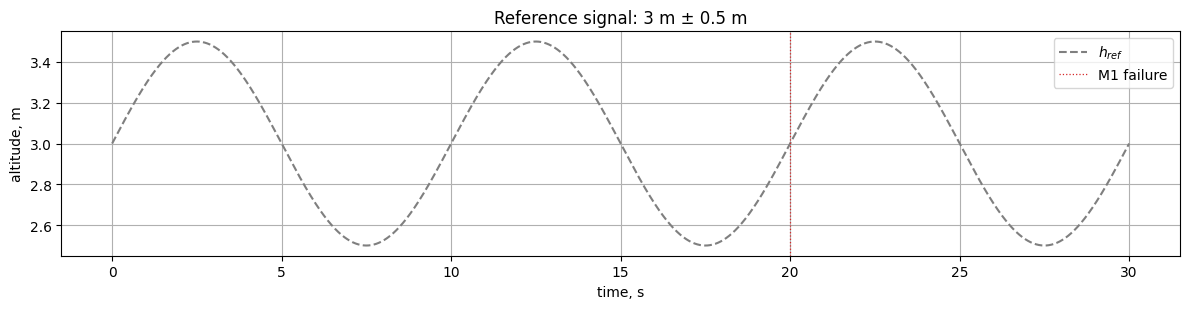

In [3]:
def height_ref_at(t):
    return HEIGHT_CENTER + SINE_AMPLITUDE * np.sin(OMEGA * t)

def z_ref_at(t):
    return -height_ref_at(t)

def z_ref_dot_at(t):
    return -SINE_AMPLITUDE * OMEGA * np.cos(OMEGA * t)

tps = np.arange(N) * DT
height_ref = height_ref_at(tps)
z_ref = -height_ref
z_ref_dot = -SINE_AMPLITUDE * OMEGA * np.cos(OMEGA * tps)

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(tps, height_ref, color="tab:gray", linestyle="--", label=r"$h_{ref}$")
ax.axvline(DAMAGE_TIME, color="tab:red", linestyle=":", linewidth=0.9, label="M1 failure")
ax.set_xlabel("time, s")
ax.set_ylabel("altitude, m")
ax.set_title("Reference signal: 3 m ± 0.5 m")
ax.grid(True)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 4. ET-DHP State and Plant Data

Two ET-DHP state spaces are used:

* altitude state: `e_z = z - z_ref`, `e_w = w_b - dz_ref/dt`;
* angular-rate state: `[p, q, r]`.

The altitude ET-DHP plant NN is trained offline on one-step transitions around the sinusoidal trajectory. There is no PD controller in the data: the rollout directly applies random `ΔT` values and zero moments.

The angular-rate ET-DHP plant NN is trained on the local model `rate_next = rate + dt * τ / J`. This is not a PD target: the actor and critic are initialized with the same ET-DHP update passes over the plant model, then continue learning online in the episode through the event trigger.


In [4]:
def damage_profile(trigger_time: float = DAMAGE_TIME) -> DamageProfile:
    return DamageProfile(
        events=[
            RotorDamageEvent(
                trigger_time=trigger_time,
                rotor_id=0,
                mu=DAMAGE_MU,
                label="m1_50pct",
            )
        ]
    )


def altitude_state(obs: np.ndarray, time_step: int) -> np.ndarray:
    t = time_step * DT
    return np.array(
        [
            obs[2] - z_ref_at(t),
            obs[5] - z_ref_dot_at(t),
        ],
        dtype=np.float64,
    )


def rate_state(obs: np.ndarray, time_step: int) -> np.ndarray:
    del time_step
    return np.asarray(obs[9:12], dtype=np.float64)


class OnlineMotorMapIdentifier:
    """Estimate motor effectiveness and the damaged virtual map online.

    The controller observes rotor-level command/effective pairs from sensors
    (in this simulation: info["omega2_cmd"] and info["omega2_eff"]). It does
    not read the damage manager's true μ.
    """

    def __init__(self, blend: float = 0.75):
        self.blend = float(blend)
        self.mu_hat = np.ones(4, dtype=np.float64)
        self.B_hat = np.eye(4, dtype=np.float64)
        self.ready = False

    def reset(self):
        self.mu_hat = np.ones(4, dtype=np.float64)
        self.B_hat = np.eye(4, dtype=np.float64)
        self.ready = False

    def observe_rotors(self, omega2_cmd: np.ndarray, omega2_eff: np.ndarray):
        omega2_cmd = np.asarray(omega2_cmd, dtype=np.float64).reshape(4)
        omega2_eff = np.asarray(omega2_eff, dtype=np.float64).reshape(4)
        mask = omega2_cmd > 1e-6
        if not np.any(mask):
            return

        idx = np.where(mask)[0]
        ratios = omega2_eff[mask] / omega2_cmd[mask]
        if self.ready:
            self.mu_hat[idx] = (1.0 - self.blend) * self.mu_hat[idx] + self.blend * ratios
        else:
            self.mu_hat[idx] = ratios
        self.mu_hat = np.clip(self.mu_hat, 0.05, 1.2)

        M = ALLOCATOR.matrix
        self.B_hat = M @ np.diag(self.mu_hat) @ ALLOCATOR.matrix_inverse
        self.ready = bool(np.all(np.isfinite(self.B_hat)) and np.linalg.cond(self.B_hat) < 1e8)

    def compensate(self, u_desired: np.ndarray) -> np.ndarray:
        u_desired = clip_virtual_command(u_desired)
        if not self.ready:
            return u_desired
        try:
            u_cmd = np.linalg.solve(self.B_hat, u_desired)
        except np.linalg.LinAlgError:
            u_cmd = u_desired.copy()
        return clip_virtual_command(u_cmd)


def clip_virtual_command(u: np.ndarray) -> np.ndarray:
    u = np.asarray(u, dtype=np.float64).copy()
    u[0] = np.clip(u[0], 0.0, THRUST_MAX)
    u[1] = np.clip(u[1], -MAX_ROLL_PITCH_TORQUE, MAX_ROLL_PITCH_TORQUE)
    u[2] = np.clip(u[2], -MAX_ROLL_PITCH_TORQUE, MAX_ROLL_PITCH_TORQUE)
    u[3] = np.clip(u[3], -MAX_YAW_TORQUE, MAX_YAW_TORQUE)
    return u


def nominal_rotor_action(u_virtual: np.ndarray) -> np.ndarray:
    return ALLOCATOR.unmix(clip_virtual_command(u_virtual))


def collect_altitude_pe_rollout(n_samples: int = 1600, seed: int = 0, pe_amp: float = 8.0):
    rng = np.random.default_rng(seed)
    states, actions, next_states = [], [], []

    for _ in range(2):
        for _k in range(n_samples):
            t = float(rng.uniform(0.0, T_END - DT))
            x = np.array(
                [
                    rng.uniform(-0.8, 0.8),
                    rng.uniform(-0.8, 0.8),
                ],
                dtype=np.float64,
            )
            x0 = np.zeros(12)
            x0[2] = z_ref_at(t) + x[0]
            x0[5] = z_ref_dot_at(t) + x[1]
            model = NonlinearQuadrotor(x0=x0, dt=DT, integrator="rk4")

            dT = float(rng.uniform(-pe_amp, pe_amp))
            total_thrust = float(np.clip(T_HOVER + dT, 0.0, THRUST_MAX))
            model.run_step(np.array([total_thrust, 0.0, 0.0, 0.0], dtype=float))

            x_next = np.array(
                [
                    model.current_state[2] - z_ref_at(t + DT),
                    model.current_state[5] - z_ref_dot_at(t + DT),
                ],
                dtype=np.float64,
            )
            states.append(x)
            actions.append([total_thrust - T_HOVER])
            next_states.append(x_next)

    return np.asarray(states), np.asarray(actions), np.asarray(next_states)


def collect_rate_pe_rollout(n_samples: int = 8000, seed: int = 2, torque_amp: float = 0.85):
    rng = np.random.default_rng(seed)
    states, actions, next_states = [], [], []

    for _ in range(n_samples):
        rates = rng.uniform(-0.7, 0.7, size=3)
        tau = rng.uniform(-torque_amp, torque_amp, size=3)
        tau[2] = rng.uniform(-MAX_YAW_TORQUE, MAX_YAW_TORQUE)
        next_rates = rates + DT * tau / INERTIA
        states.append(rates)
        actions.append(tau)
        next_states.append(next_rates)

    return np.asarray(states), np.asarray(actions), np.asarray(next_states)


s_alt_arr, a_alt_arr, n_alt_arr = collect_altitude_pe_rollout(n_samples=1600, seed=0, pe_amp=8.0)
s_rate_arr, a_rate_arr, n_rate_arr = collect_rate_pe_rollout(n_samples=8000, seed=2, torque_amp=0.85)

print(f"Altitude PE-rollout: {len(s_alt_arr)} transitions")
print(f"  e_z range: [{s_alt_arr[:, 0].min():+.3f}, {s_alt_arr[:, 0].max():+.3f}] m")
print(f"  e_w range: [{s_alt_arr[:, 1].min():+.3f}, {s_alt_arr[:, 1].max():+.3f}] m/s")
print(f"  ΔT range : [{a_alt_arr[:, 0].min():+.3f}, {a_alt_arr[:, 0].max():+.3f}] N")
print(f"Rate PE-rollout: {len(s_rate_arr)} transitions")
print(f"  p/q/r range: [{s_rate_arr.min():+.3f}, {s_rate_arr.max():+.3f}] rad/s")
print(f"  τ range    : [{a_rate_arr.min():+.3f}, {a_rate_arr.max():+.3f}] N*m")


Altitude PE-rollout: 3200 transitions
  e_z range: [-0.800, +0.800] m
  e_w range: [-0.799, +0.800] m/s
  ΔT range : [-7.997, +7.991] N
Rate PE-rollout: 8000 transitions
  p/q/r range: [-0.700, +0.700] rad/s
  τ range    : [-0.850, +0.850] N*m


## 5. ET-DHP Configuration

Altitude ET-DHP:

* `Q = diag(80, 10)` penalizes altitude error and vertical-speed error;
* `R = 0.002` keeps the actor aggressive enough without forcing constant thrust saturation;
* `u_bound = 12.6 N` is consistent with the physical limit `T ≤ 30 N`.

Angular-rate ET-DHP:

* state `[p, q, r]`, action `[τx, τy, τz]`;
* the actor is bounded in moment channels, and the final clipping keeps yaw physically moderate;
* the actor and critic are initialized by ET-DHP update passes, not by supervised PD.


In [5]:
def build_altitude_agent(seed: int = 42) -> ETDHPAgent:
    cfg = ETDHPConfig(
        actor_hidden=(16, 16),
        critic_hidden=(16, 16),
        model_hidden=(32, 32),
        actor_lr=1e-3,
        critic_lr=1e-3,
        model_lr=1e-3,
        model_epochs=80,
        Q=[80.0, 10.0],
        R=[0.002],
        gamma=0.97,
        num_epochs_per_trigger=2,
        u_bound=MAX_DELTA_T,
        rho=0.08,
        trigger_floor=5e-4,
        weight_init_scale=0.2,
        seed=seed,
    )
    return ETDHPAgent(n_state=2, n_control=1, config=cfg)


def build_rate_agent(seed: int = 7) -> ETDHPAgent:
    cfg = ETDHPConfig(
        actor_hidden=(24, 24),
        critic_hidden=(24, 24),
        model_hidden=(32, 32),
        actor_lr=2e-3,
        critic_lr=1e-3,
        model_lr=1e-3,
        model_epochs=100,
        Q=[20.0, 20.0, 8.0],
        R=[0.0008, 0.0008, 0.002],
        gamma=0.95,
        num_epochs_per_trigger=3,
        u_bound=MAX_ROLL_PITCH_TORQUE,
        rho=0.05,
        trigger_floor=1e-5,
        weight_init_scale=0.15,
        seed=seed,
    )
    return ETDHPAgent(n_state=3, n_control=3, config=cfg)


def offline_etdhp_policy_pretrain(
    agent: ETDHPAgent,
    n_samples: int,
    sweeps: int,
    seed: int,
    low: float,
    high: float,
):
    rng = np.random.default_rng(seed)
    states = rng.uniform(low, high, size=(n_samples, agent.n_state))

    losses = []
    for _ in range(sweeps):
        for idx in rng.permutation(n_samples):
            actor_loss, critic_loss = agent._run_inner_updates(states[idx])
            losses.append((actor_loss, critic_loss))
    return losses


altitude_template = build_altitude_agent(seed=42)
print("Pre-training altitude plant-NN...")
alt_plant_losses = altitude_template.fit_plant_model(
    s_alt_arr,
    a_alt_arr,
    n_alt_arr,
    epochs=80,
    batch_size=256,
    verbose=False,
)
print(f"  altitude plant initial MSE: {alt_plant_losses[0]:.3e}")
print(f"  altitude plant final   MSE: {alt_plant_losses[-1]:.3e}")

print("Offline altitude ET-DHP actor/critic pretrain...")
alt_policy_losses = offline_etdhp_policy_pretrain(
    altitude_template,
    n_samples=600,
    sweeps=2,
    seed=123,
    low=-0.9,
    high=0.9,
)
print(f"  last altitude actor loss : {alt_policy_losses[-1][0]:.3e}")
print(f"  last altitude critic loss: {alt_policy_losses[-1][1]:.3e}")

rate_template = build_rate_agent(seed=7)
print("Pre-training angular-rate plant-NN...")
rate_plant_losses = rate_template.fit_plant_model(
    s_rate_arr,
    a_rate_arr,
    n_rate_arr,
    epochs=100,
    batch_size=512,
    verbose=False,
)
print(f"  rate plant initial MSE: {rate_plant_losses[0]:.3e}")
print(f"  rate plant final   MSE: {rate_plant_losses[-1]:.3e}")

print("Offline angular-rate ET-DHP actor/critic pretrain...")
rate_policy_losses = offline_etdhp_policy_pretrain(
    rate_template,
    n_samples=1200,
    sweeps=4,
    seed=222,
    low=-0.7,
    high=0.7,
)
print(f"  last rate actor loss : {rate_policy_losses[-1][0]:.3e}")
print(f"  last rate critic loss: {rate_policy_losses[-1][1]:.3e}")


Pre-training altitude plant-NN...


  altitude plant initial MSE: 2.208e-01
  altitude plant final   MSE: 4.706e-05
Offline altitude ET-DHP actor/critic pretrain...


  last altitude actor loss : 1.935e+01
  last altitude critic loss: 6.475e+03
Pre-training angular-rate plant-NN...


  rate plant initial MSE: 1.902e-01
  rate plant final   MSE: 4.891e-05
Offline angular-rate ET-DHP actor/critic pretrain...


  last rate actor loss : 7.148e-01
  last rate critic loss: 1.435e+00


## 6. Scenario Rollout

Run two episodes with identical learned weights:

* **healthy** — no failure;
* **damage** — M1 loses effectiveness at `t = 20 s`.

The ET-DHP command is now four-channel in virtual coordinates:

```python
u_desired = [T_hover + ΔT_altitude_ETDHP, τx_rate_ETDHP, τy_rate_ETDHP, τz_rate_ETDHP]
```

Before the failure, nominal allocation is used. After the failure is detected, online motor-map identification is enabled:

```python
omega2_eff ≈ diag(mu_hat) @ omega2_cmd
B_hat = M @ diag(mu_hat) @ inv(M)
u_cmd = solve(B_hat, u_desired)
action = ALLOCATOR.unmix(u_cmd)
```

The true `μ` is not passed to the controller, and there is no precomputed `FAULT_RECONFIG` at runtime.


In [6]:
def clone_altitude_agent_from_template() -> ETDHPAgent:
    agent = build_altitude_agent(seed=42)
    agent.actor.load_state_dict(copy.deepcopy(altitude_template.actor.state_dict()))
    agent.critic.load_state_dict(copy.deepcopy(altitude_template.critic.state_dict()))
    agent.plant_model.load_state_dict(copy.deepcopy(altitude_template.plant_model.state_dict()))
    return agent


def clone_rate_agent_from_template() -> ETDHPAgent:
    agent = build_rate_agent(seed=7)
    agent.actor.load_state_dict(copy.deepcopy(rate_template.actor.state_dict()))
    agent.critic.load_state_dict(copy.deepcopy(rate_template.critic.state_dict()))
    agent.plant_model.load_state_dict(copy.deepcopy(rate_template.plant_model.state_dict()))
    return agent


def run_episode(altitude_agent: ETDHPAgent, rate_agent: ETDHPAgent, with_damage: bool):
    x0 = np.zeros(12)
    x0[2] = Z_CENTER
    env = NonlinearQuadrotorEnv(
        initial_state=x0,
        number_time_steps=N,
        dt=DT,
        action_space="rotor",
        damage_profile=damage_profile(DAMAGE_TIME) if with_damage else None,
    )
    obs, _ = env.reset()
    altitude_agent.reset()
    rate_agent.reset()

    z_log = np.zeros(N)
    w_log = np.zeros(N)
    T_log = np.zeros(N)
    dT_log = np.zeros(N)
    T_cmd_log = np.zeros(N)
    tau_log = np.zeros((N, 3))
    trig_alt_log = np.zeros(N, dtype=int)
    trig_rate_log = np.zeros(N, dtype=int)
    mu_log = np.ones((N, 4))
    mu_hat_log = np.ones((N, 4))
    id_ready_log = np.zeros(N, dtype=int)
    B_hat_log = np.repeat(np.eye(4)[None, :, :], N, axis=0)
    damage_step = -1
    fault_seen = False
    fault_id = OnlineMotorMapIdentifier()

    for k in tqdm(range(N - 1)):
        z_log[k] = obs[2]
        w_log[k] = obs[5]

        altitude_agent.predict(altitude_state(obs, k), None, k)
        dT = float(np.clip(altitude_agent.last_action()[0], -MAX_DELTA_T, MAX_DELTA_T))
        total_thrust = float(np.clip(T_HOVER + dT, 0.0, THRUST_MAX))

        rate_agent.predict(rate_state(obs, k), None, k)
        tau = np.asarray(rate_agent.last_action(), dtype=np.float64)
        tau[0] = np.clip(tau[0], -MAX_ROLL_PITCH_TORQUE, MAX_ROLL_PITCH_TORQUE)
        tau[1] = np.clip(tau[1], -MAX_ROLL_PITCH_TORQUE, MAX_ROLL_PITCH_TORQUE)
        tau[2] = np.clip(tau[2], -MAX_YAW_TORQUE, MAX_YAW_TORQUE)

        u_desired = np.array([total_thrust, tau[0], tau[1], tau[2]], dtype=np.float64)
        if fault_seen:
            u_cmd = fault_id.compensate(u_desired)
        else:
            u_cmd = clip_virtual_command(u_desired)

        action = nominal_rotor_action(u_cmd)
        obs_next, _, _, trunc, info = env.step(action)

        alt_metrics = altitude_agent.learn(altitude_state(obs_next, k + 1), None, k, dt=DT)
        rate_metrics = rate_agent.learn(rate_state(obs_next, k + 1), None, k, dt=DT)
        trig_alt_log[k] = int(alt_metrics.get("triggered", 0.0))
        trig_rate_log[k] = int(rate_metrics.get("triggered", 0.0))

        if "damage_events_triggered" in info and damage_step < 0:
            damage_step = k + 1
            fault_seen = True
            fault_id.reset()
        if fault_seen and "omega2_cmd" in info and "omega2_eff" in info:
            fault_id.observe_rotors(info["omega2_cmd"], info["omega2_eff"])

        if env.damage_manager is not None:
            mu_log[k + 1] = env.damage_manager.state.mu
        else:
            mu_log[k + 1] = mu_log[k]
        mu_hat_log[k + 1] = fault_id.mu_hat
        id_ready_log[k + 1] = int(fault_id.ready)
        B_hat_log[k + 1] = fault_id.B_hat

        T_log[k] = total_thrust
        dT_log[k] = total_thrust - T_HOVER
        T_cmd_log[k] = u_cmd[0]
        tau_log[k] = tau
        obs = obs_next
        if trunc:
            break

    z_log[-1] = obs[2]
    w_log[-1] = obs[5]
    T_log[-1] = T_log[-2]
    dT_log[-1] = dT_log[-2]
    T_cmd_log[-1] = T_cmd_log[-2]
    tau_log[-1] = tau_log[-2]

    return (
        z_log,
        w_log,
        T_log,
        dT_log,
        T_cmd_log,
        tau_log,
        trig_alt_log,
        trig_rate_log,
        mu_log,
        mu_hat_log,
        id_ready_log,
        B_hat_log,
        damage_step,
    )


print("Healthy episode...")
agent_h_alt = clone_altitude_agent_from_template()
agent_h_rate = clone_rate_agent_from_template()
(
    z_h,
    w_h,
    T_h,
    dT_h,
    Tcmd_h,
    tau_h,
    trig_alt_h,
    trig_rate_h,
    mu_h,
    muhat_h,
    id_h,
    B_h,
    _,
) = run_episode(agent_h_alt, agent_h_rate, with_damage=False)
trig_h = np.maximum(trig_alt_h, trig_rate_h)

print("Damage episode: M1 50% at t=20s...")
agent_d_alt = clone_altitude_agent_from_template()
agent_d_rate = clone_rate_agent_from_template()
(
    z_d,
    w_d,
    T_d,
    dT_d,
    Tcmd_d,
    tau_d,
    trig_alt_d,
    trig_rate_d,
    mu_d,
    muhat_d,
    id_d,
    B_d,
    dmg_step,
) = run_episode(agent_d_alt, agent_d_rate, with_damage=True)
trig_d = np.maximum(trig_alt_d, trig_rate_d)

ready_idx = np.where(id_d == 1)[0]
ready_text = "not ready" if ready_idx.size == 0 else f"ready at t={ready_idx[0] * DT:.2f} s"
print(f"  failure detected at step {dmg_step} (t={dmg_step * DT:.2f} s)")
print(f"  online B_hat: {ready_text}")
print(f"  final mu_hat: {np.array2string(muhat_d[-1], precision=3)}")


Healthy episode...


  0%|          | 0/3000 [00:00<?, ?it/s]

  3%|▎         | 97/3000 [00:00<00:03, 966.78it/s]

  8%|▊         | 245/3000 [00:00<00:02, 1259.51it/s]

 12%|█▏        | 371/3000 [00:00<00:03, 792.59it/s] 

...

 75%|███████▌  | 2251/3000 [00:01<00:00, 2668.49it/s]

 86%|████████▌ | 2565/3000 [00:01<00:00, 2800.95it/s]

 96%|█████████▌| 2873/3000 [00:01<00:00, 2878.87it/s]

100%|██████████| 3000/3000 [00:01<00:00, 1884.63it/s]

  failure detected at step 2000 (t=20.00 s)
  online B_hat: ready at t=20.00 s
  final mu_hat: [0.5 1.  1.  1. ]


## 7. Tracking: Healthy vs M1 Damage

If compensation works, the red trajectory after `t = 20 s` should remain very close to the blue healthy trajectory.


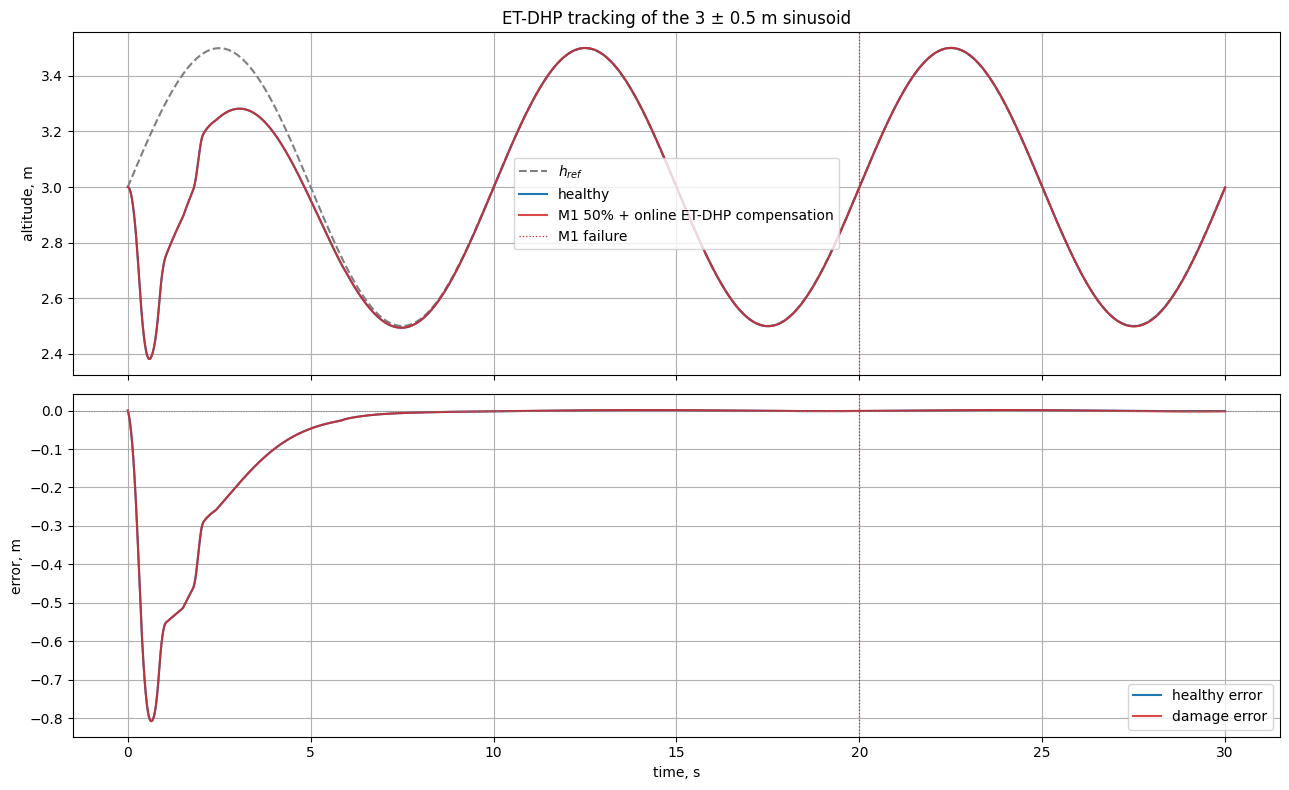

In [7]:
height_h = -z_h
height_d = -z_d
err_h = height_h - height_ref
err_d = height_d - height_ref

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(tps, height_ref, "--", color="tab:gray", label=r"$h_{ref}$")
axes[0].plot(tps, height_h, color="tab:blue", label="healthy")
axes[0].plot(tps, height_d, color="tab:red", alpha=0.85, label="M1 50% + online ET-DHP compensation")
axes[0].axvline(DAMAGE_TIME, color="tab:red", linestyle=":", linewidth=0.9, label="M1 failure")
axes[0].set_ylabel("altitude, m")
axes[0].set_title("ET-DHP tracking of the 3 ± 0.5 m sinusoid")
axes[0].grid(True)
axes[0].legend(loc="best")

axes[1].plot(tps, err_h, color="tab:blue", label="healthy error")
axes[1].plot(tps, err_d, color="tab:red", alpha=0.85, label="damage error")
axes[1].axhline(0, color="tab:gray", linestyle=":", linewidth=0.7)
axes[1].axvline(DAMAGE_TIME, color="tab:red", linestyle=":", linewidth=0.9)
axes[1].set_xlabel("time, s")
axes[1].set_ylabel("error, m")
axes[1].grid(True)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


## 8. Control, Triggers, and Motor State

After the failure, `μ_1` drops inside the environment. The controller does not receive this value directly: it estimates `mu_hat` from observed rotor-level pairs `omega2_cmd -> omega2_eff`, builds `B_hat`, and solves `solve(B_hat, u_desired)`. The moments after the first asymmetric step are commanded by the angular-rate ET-DHP actor, not by a PD loop.


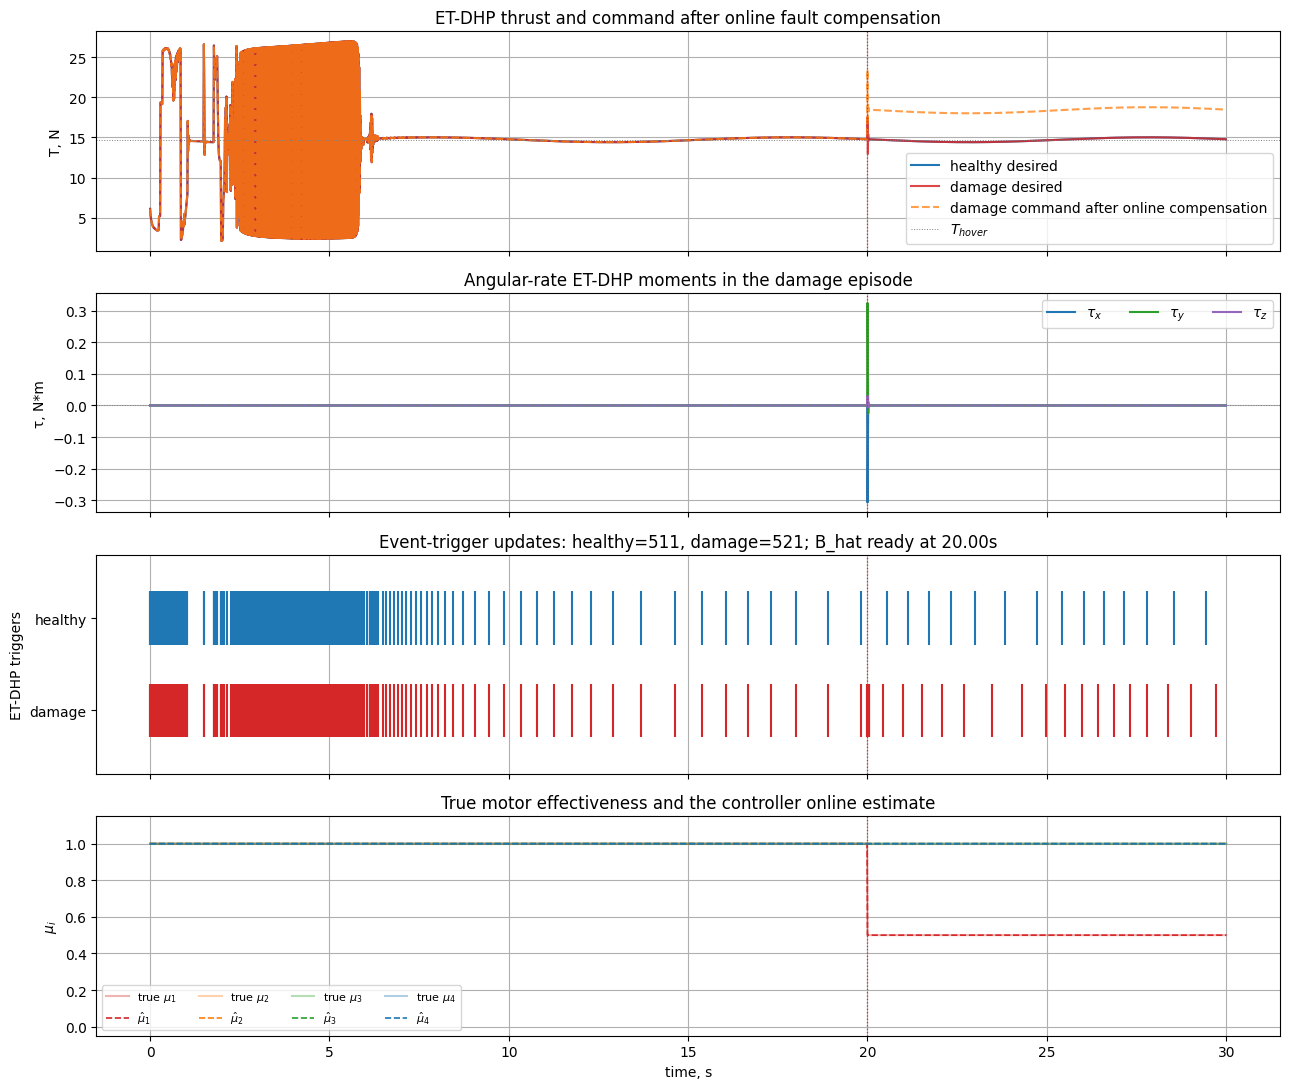

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

axes[0].plot(tps[:-1], T_h[:-1], color="tab:blue", label="healthy desired")
axes[0].plot(tps[:-1], T_d[:-1], color="tab:red", alpha=0.85, label="damage desired")
axes[0].plot(tps[:-1], Tcmd_d[:-1], color="tab:orange", alpha=0.75, linestyle="--", label="damage command after online compensation")
axes[0].axhline(T_HOVER, color="tab:gray", linestyle=":", linewidth=0.7, label=r"$T_{hover}$")
axes[0].axvline(DAMAGE_TIME, color="tab:red", linestyle=":", linewidth=0.9)
axes[0].set_ylabel("T, N")
axes[0].set_title("ET-DHP thrust and command after online fault compensation")
axes[0].grid(True)
axes[0].legend(loc="best")

axes[1].plot(tps[:-1], tau_d[:-1, 0], color="tab:blue", label=r"$τ_x$")
axes[1].plot(tps[:-1], tau_d[:-1, 1], color="tab:green", label=r"$τ_y$")
axes[1].plot(tps[:-1], tau_d[:-1, 2], color="tab:purple", label=r"$τ_z$")
axes[1].axhline(0, color="tab:gray", linestyle=":", linewidth=0.7)
axes[1].axvline(DAMAGE_TIME, color="tab:red", linestyle=":", linewidth=0.9)
axes[1].set_ylabel("τ, N*m")
axes[1].set_title("Angular-rate ET-DHP moments in the damage episode")
axes[1].grid(True)
axes[1].legend(loc="best", ncol=3)

axes[2].eventplot(np.where(trig_h == 1)[0] * DT, colors="tab:blue", lineoffsets=0.8, linelengths=0.35)
axes[2].eventplot(np.where(trig_d == 1)[0] * DT, colors="tab:red", lineoffsets=0.2, linelengths=0.35)
axes[2].axvline(DAMAGE_TIME, color="tab:red", linestyle=":", linewidth=0.9)
axes[2].set_yticks([0.2, 0.8], ["damage", "healthy"])
axes[2].set_ylabel("ET-DHP triggers")
axes[2].grid(True, axis="x")
ready_time = np.where(id_d == 1)[0]
ready_label = "not ready" if ready_time.size == 0 else f"B_hat ready at {ready_time[0] * DT:.2f}s"
axes[2].set_title(f"Event-trigger updates: healthy={int(trig_h.sum())}, damage={int(trig_d.sum())}; {ready_label}")

colors = ["tab:red", "tab:orange", "tab:green", "tab:blue"]
for i, c in enumerate(colors):
    axes[3].plot(tps, mu_d[:, i], color=c, alpha=0.35, label=fr"true $\mu_{i+1}$")
    axes[3].plot(tps, muhat_d[:, i], color=c, linestyle="--", linewidth=1.2, label=fr"$\hat\mu_{i+1}$")
axes[3].axvline(DAMAGE_TIME, color="tab:red", linestyle=":", linewidth=0.9)
axes[3].set_xlabel("time, s")
axes[3].set_ylabel(r"$\mu_i$")
axes[3].set_ylim(-0.05, 1.15)
axes[3].grid(True)
axes[3].legend(loc="lower left", ncol=4, fontsize=8)
axes[3].set_title("True motor effectiveness and the controller online estimate")

plt.tight_layout()
plt.show()


## 9. Quantitative Metrics

The main interval of interest is **20-30 s**, i.e. the 10 seconds after the failure. The **21-30 s** interval is also reported to exclude the first second after the event.


In [9]:
def tracking_metrics(err: np.ndarray, start_s: float, end_s: float):
    i0 = int(start_s / DT)
    i1 = int(end_s / DT)
    segment = err[i0:i1]
    return {
        "rmse": float(np.sqrt(np.mean(segment ** 2))),
        "mae": float(np.mean(np.abs(segment))),
        "max_abs": float(np.max(np.abs(segment))),
    }

healthy_pre = tracking_metrics(err_h, 10.0, DAMAGE_TIME)
healthy_post = tracking_metrics(err_h, DAMAGE_TIME, T_END)
damage_pre = tracking_metrics(err_d, 10.0, DAMAGE_TIME)
damage_post = tracking_metrics(err_d, DAMAGE_TIME, T_END)
damage_post_late = tracking_metrics(err_d, DAMAGE_TIME + 1.0, T_END)
ready_idx = np.where(id_d == 1)[0]
ready_msg = "not ready" if ready_idx.size == 0 else f"{ready_idx[0] * DT:.2f} s"

print("=" * 68)
print("Altitude tracking metrics")
print(f"Healthy 10–20 s: RMSE={healthy_pre['rmse']:.4f} m, MAE={healthy_pre['mae']:.4f} m")
print(f"Healthy 20–30 s: RMSE={healthy_post['rmse']:.4f} m, MAE={healthy_post['mae']:.4f} m")
print()
print(f"Damage  10–20 s: RMSE={damage_pre['rmse']:.4f} m, MAE={damage_pre['mae']:.4f} m")
print(f"Damage  20–30 s: RMSE={damage_post['rmse']:.4f} m, MAE={damage_post['mae']:.4f} m, max|e|={damage_post['max_abs']:.4f} m")
print(f"Damage  21–30 s: RMSE={damage_post_late['rmse']:.4f} m, MAE={damage_post_late['mae']:.4f} m, max|e|={damage_post_late['max_abs']:.4f} m")
print()
print(f"Post-fault degradation vs healthy: ×{damage_post['rmse'] / healthy_post['rmse']:.3f}")
print(f"Final damage error: {err_d[-1]:+.4f} m")
print(f"B_hat ready: {ready_msg}")
print(f"final mu_hat: {np.array2string(muhat_d[-1], precision=3)}")
print(f"Healthy triggers: altitude={int(trig_alt_h.sum())}, rate={int(trig_rate_h.sum())}")
print(f"Damage triggers: altitude={int(trig_alt_d.sum())}, rate={int(trig_rate_d.sum())}")


Altitude tracking metrics
Healthy 10–20 s: RMSE=0.0010 m, MAE=0.0009 m
Healthy 20–30 s: RMSE=0.0010 m, MAE=0.0009 m

Damage  10–20 s: RMSE=0.0010 m, MAE=0.0009 m
Damage  20–30 s: RMSE=0.0014 m, MAE=0.0012 m, max|e|=0.0024 m
Damage  21–30 s: RMSE=0.0014 m, MAE=0.0012 m, max|e|=0.0024 m

Post-fault degradation vs healthy: ×1.368
Final damage error: -0.0021 m
B_hat ready: 20.00 s
final mu_hat: [0.5 1.  1.  1. ]
Healthy triggers: altitude=511, rate=1
Damage triggers: altitude=519, rate=8


## 10. Conclusions

* Runtime remains PD-free: thrust is commanded by altitude ET-DHP, and moments are commanded by angular-rate ET-DHP.
* The allocator remains nominal: the true `μ` from the damage manager is not passed to the controller, and there is no `omega² / μ` division using known effectiveness.
* There is no precomputed `FAULT_RECONFIG`. The controller estimates `mu_hat` online from `omega2_cmd -> omega2_eff`, then builds `B_hat = M diag(mu_hat) M⁻¹`.
* Once `B_hat` is ready, the controller uses `solve(B_hat, u_desired)`, and ET-DHP continues tracking the sinusoid after the M1 failure.
* The residual error is reported in the `20-30 s` and `21-30 s` metric windows.
